# Model Evaluation
Evaluate the trained forecasting model.

In [1]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path('..').resolve()
MODEL_PATH = PROJECT_ROOT/'artifacts/models/temperature_forecaster.joblib'
FEATURE_PATH = PROJECT_ROOT/'data/gold/temperature_features.parquet'
print(PROJECT_ROOT)

C:\Users\ngota\OneDrive\Desktop\Github\Resume-Projects\Ocean Data ML Platform with RAG


In [2]:
features = pd.read_parquet(FEATURE_PATH)
features.head()

,latitude,time,longitude,value,source_variable,source_file,units,dataset_id,canonical_variable,normalized_value,normalized_unit,provenance_transform,time_ts,hour,dayofyear,lag_1,lag_3,lag_6
0,18.34744,2021-05-05 00:00:00,-64.66539,27.2723,TEMP_C,data\raw\noaa\noaa_sst.nc,Celsius,noaa,sea_water_temperature,27.2723,degC,canonicalize_and_normalize,2021-05-05 07:00:00,0,125,27.2741,27.2868,27.3033
1,18.34744,2021-05-05 00:00:00,-64.66539,27.2734,TEMP_C,data\raw\noaa\noaa_sst.nc,Celsius,noaa,sea_water_temperature,27.2734,degC,canonicalize_and_normalize,2021-05-05 07:00:00,0,125,27.2723,27.2814,27.2945
2,18.34744,2021-05-05 00:00:00,-64.66539,27.2756,TEMP_C,data\raw\noaa\noaa_sst.nc,Celsius,noaa,sea_water_temperature,27.2756,degC,canonicalize_and_normalize,2021-05-05 07:00:00,0,125,27.2734,27.2741,27.2892
3,18.34744,2021-05-05 00:00:00,-64.66539,27.2759,TEMP_C,data\raw\noaa\noaa_sst.nc,Celsius,noaa,sea_water_temperature,27.2759,degC,canonicalize_and_normalize,2021-05-05 07:00:00,0,125,27.2756,27.2723,27.2868
4,18.34744,2021-05-05 00:00:00,-64.66539,27.2752,TEMP_C,data\raw\noaa\noaa_sst.nc,Celsius,noaa,sea_water_temperature,27.2752,degC,canonicalize_and_normalize,2021-05-05 07:00:00,0,125,27.2759,27.2734,27.2814


In [3]:
bundle = joblib.load(MODEL_PATH)
model = bundle['model']
feature_cols = bundle['feature_cols']
print('Features:', feature_cols)

Features: ['hour', 'dayofyear', 'lag_1', 'lag_3', 'lag_6']


In [4]:
target = 'normalized_value'
X = features[feature_cols]
y = features[target]
split = int(len(X) * 0.8)
X_test = X.iloc[split:]
y_test = y.iloc[split:]
pred = model.predict(X_test)

In [5]:
results = pd.DataFrame({
    'actual': y_test,
    'predicted': pred
})

results['error'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,error
2954454,12.6248,12.628074,-0.003274
2954455,12.6266,12.628074,-0.001474
2954456,12.6242,12.629336,-0.005136
2954457,12.6197,12.629336,-0.009636
2954458,12.6185,12.612507,0.005993


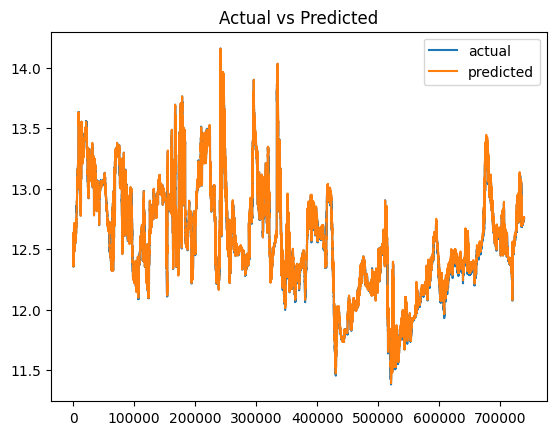

In [6]:
plt.plot(results['actual'].values, label='actual')
plt.plot(results['predicted'].values, label='predicted')
plt.legend()
plt.title('Actual vs Predicted')
plt.show()

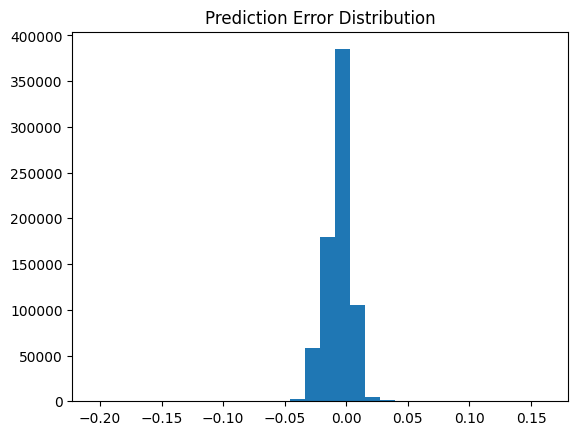

In [7]:
plt.hist(results['error'], bins=30)
plt.title('Prediction Error Distribution')
plt.show()